# RQ18 — Engineered Acoustic Representation vs End-to-End Waveform Learning

## Research question

**Does end-to-end learning directly from the dual-channel raw waveform improve password-level generalisation compared with the engineered 695-dimensional acoustic representation?**

This notebook is a controlled dissertation experiment. It does **not** replace MAIN v8 in the operational unlocking system.

### Fixed comparison

| Condition | Representation | Model |
|---|---|---|
| A | Engineered 695-D | Logistic Regression |
| B | Engineered 695-D | CNN |
| C | Raw dual-channel waveform | 1D CNN |

The comparison reuses the same B01–B07 data, password-level LOPO folds, wheel-specific handling, separate CW/CCW domains and matched A/B score fusion used in `Final_Model_Training.ipynb`.

For the raw condition, only the input representation changes: `audio_dual.wav` is sliced from `SCAN_START` to `SCAN_END`, zero-padded to a fixed length, and scaled using statistics estimated from the outer-training passwords only. No per-recording amplitude normalisation is applied.

## Evaluation design

- **Outer evaluation:** seven-fold leave-one-password-out (B01–B07).
- **Unit of evaluation:** A/B-fused 10-candidate decision.
- **Primary metric:** Top-1 accuracy.
- **Secondary metrics:** Top-2, Top-3, MRR, mean true rank, Macro-F1, per-password Top-1, password-level SD, worst-password Top-1, per-wheel and per-direction Top-1.
- **Raw CNN stochasticity:** three fixed random seeds are run independently. Results are reported as the mean of the three runs; they are not ensembled.
- **Early stopping:** one complete password from the outer-training set is used as grouped inner validation, following the deterministic rule used by the final model-comparison notebook.
- **Shortcut controls:** no password/profile/repeat/ordinal/digit identifier is supplied as a model input.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import importlib.util
import json
import sys

import numpy as np
import pandas as pd
import torch

MYDRIVE = Path('/content/drive/MyDrive')


def locate_results_root(mydrive):
    project_root = mydrive / 'Padlock_Reproduction_v1'
    candidates = [
        project_root / 'results',
        project_root / 'Padlock_Reproduction_v1' / 'results',
    ]
    for root in candidates:
        marker = root / '07_RQ7_Absolute_vs_Relative' / 'RQ7_candidate_manifest.csv'
        if marker.exists():
            return root
    raise FileNotFoundError('Could not locate the active Padlock_Reproduction_v1/results folder.')


RESULTS_ROOT = locate_results_root(MYDRIVE)
RESULT_DIR = RESULTS_ROOT / '18_RQ18_Engineered_vs_Raw_Waveform'
MODULE_PATH = RESULT_DIR / 'RQ18_raw_vs_engineered.py'

if not MODULE_PATH.exists():
    raise FileNotFoundError(MODULE_PATH)

spec = importlib.util.spec_from_file_location('rq18', MODULE_PATH)
rq18 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rq18)

print('Results root:', RESULTS_ROOT)
print('RQ18 folder :', RESULT_DIR)
print('PyTorch     :', torch.__version__)
print('CUDA        :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU         :', torch.cuda.get_device_name(0))
else:
    raise RuntimeError('Switch the Colab runtime to GPU before running the raw-waveform LOPO experiment.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results root: /content/drive/MyDrive/Padlock_Reproduction_v1/results
RQ18 folder : /content/drive/MyDrive/Padlock_Reproduction_v1/results/18_RQ18_Engineered_vs_Raw_Waveform
PyTorch     : 2.11.0+cu128
CUDA        : True
GPU         : Tesla T4


In [4]:
MANIFEST_PATH = RESULTS_ROOT / '07_RQ7_Absolute_vs_Relative' / 'RQ7_candidate_manifest.csv'
BASELINE_PATH = RESULTS_ROOT / 'Final_Model_Training' / 'Final_Model_LOPO_Predictions.csv'
RAW_ROOT = rq18.locate_raw_root(MYDRIVE)
WORK_DIR = Path('/content/rq18_work')
WORK_DIR.mkdir(parents=True, exist_ok=True)

manifest = rq18.load_manifest(MANIFEST_PATH)
baseline_decisions = pd.read_csv(BASELINE_PATH)

baseline_decisions = baseline_decisions[
    baseline_decisions['family'].isin(['Logistic Regression', 'CNN'])
].copy()

assert len(manifest) == 8400
assert manifest['batch'].nunique() == 7
assert manifest['decision_uid'].nunique() == 840
assert len(baseline_decisions) == 840
assert baseline_decisions.groupby('family').size().eq(420).all()

archive_summary = rq18.raw_archive_summary(RAW_ROOT)
assert archive_summary['zip_exists'].all()
assert archive_summary['zip_mb'].gt(50).all()

print('Manifest      :', MANIFEST_PATH)
print('Raw ZIP root  :', RAW_ROOT)
print('Baseline file :', BASELINE_PATH)
print('Candidates    :', len(manifest))
print('Decisions     :', manifest['decision_uid'].nunique())
print('Passwords     :', manifest['batch'].drop_duplicates().tolist())
print('Baseline rows :', baseline_decisions.groupby('family').size().to_dict())
print('Full raw archives used by RQ18:')
display(archive_summary[['batch', 'zip_mb']].style.format({'zip_mb': '{:.1f} MB'}))


Manifest      : /content/drive/MyDrive/Padlock_Reproduction_v1/results/07_RQ7_Absolute_vs_Relative/RQ7_candidate_manifest.csv
Raw ZIP root  : /content/drive/MyDrive/dataset/raw
Baseline file : /content/drive/MyDrive/Padlock_Reproduction_v1/results/Final_Model_Training/Final_Model_LOPO_Predictions.csv
Candidates    : 8400
Decisions     : 840
Passwords     : ['B01_2085', 'B02_4369', 'B03_5720', 'B04_6893', 'B05_7246', 'B06_8451', 'B07_9638']
Baseline rows : {'CNN': 420, 'Logistic Regression': 420}
Full raw archives used by RQ18:


,batch,zip_mb
0,B01_2085,267.5 MB
1,B02_4369,267.0 MB
2,B03_5720,264.7 MB
3,B04_6893,265.9 MB
4,B05_7246,269.5 MB
5,B06_8451,277.6 MB
6,B07_9638,275.4 MB


## Baseline check

Before touching the raw waveform, verify that the two engineered-feature reference conditions reproduce the already frozen paper benchmark. Expected values are approximately:

- 695-D + Logistic Regression: **86.0% Top-1**
- 695-D + CNN: **80.5% Top-1**

These values are reused from `Final_Model_Training`; they are not retrained here.

In [5]:
baseline_check = (
    baseline_decisions.groupby('family', as_index=False)
    .agg(
        n_decisions=('top1', 'size'),
        top1=('top1', 'mean'),
        top2=('top2', 'mean'),
        top3=('top3', 'mean'),
        mrr=('reciprocal_rank', 'mean'),
        mean_true_rank=('true_rank', 'mean'),
    )
)

display(baseline_check.style.format({
    'top1': '{:.3f}',
    'top2': '{:.3f}',
    'top3': '{:.3f}',
    'mrr': '{:.3f}',
    'mean_true_rank': '{:.3f}',
}))

lr_top1 = float(baseline_check.loc[baseline_check['family'] == 'Logistic Regression', 'top1'].iloc[0])
cnn_top1 = float(baseline_check.loc[baseline_check['family'] == 'CNN', 'top1'].iloc[0])
assert abs(lr_top1 - 0.8595238095) < 1e-6
assert abs(cnn_top1 - 0.8047619048) < 1e-6
print('Baseline check passed.')

,family,n_decisions,top1,top2,top3,mrr,mean_true_rank
0,CNN,420,0.805,0.936,0.969,0.888,1.314
1,Logistic Regression,420,0.860,0.955,0.979,0.920,1.229


Baseline check passed.


## Build the raw-waveform cache

This uses the **same I/O strategy adopted for the earlier RQs** after the performance audit:

1. use the original full Dataset v1 batch ZIP (`B01_2085.zip` … `B07_9638.zip`);
2. copy one large ZIP from mounted Drive to `/content` once;
3. extract that batch locally;
4. read all 1,200 `audio_dual.wav` + `events.csv` pairs from local Colab storage;
5. extract exactly `SCAN_START → SCAN_END`;
6. delete the local extracted batch before moving to the next ZIP;
7. save the completed persistent waveform cache back to the RQ18 result folder.

The code deliberately refuses the similarly named tiny archives and does **not** fall back to reading thousands of individual WAV/CSV files through the mounted Google Drive tree.

The resulting cache has shape:

`8400 candidates × 2 channels × 12288 samples`


In [6]:
raw_waveforms, raw_lengths = rq18.prepare_raw_cache(
    manifest=manifest,
    raw_root=RAW_ROOT,
    result_dir=RESULT_DIR,
    work_dir=WORK_DIR,
)

print('Cache shape:', raw_waveforms.shape)
print('Length min/median/max:', int(raw_lengths.min()), float(np.median(raw_lengths)), int(raw_lengths.max()))
print('Target samples:', rq18.TARGET_SAMPLES)
assert raw_waveforms.shape == (8400, 2, rq18.TARGET_SAMPLES)
assert raw_lengths.max() <= rq18.TARGET_SAMPLES

[B01_2085] copy raw ZIP to local Colab (267.5 MB)
[B01_2085] extract ZIP locally
[B01_2085] cache 1,200 runs from local disk
     200/1200
     400/1200
     600/1200
     800/1200
    1000/1200
    1200/1200
[B01_2085] complete
[B02_4369] copy raw ZIP to local Colab (267.0 MB)
[B02_4369] extract ZIP locally
[B02_4369] cache 1,200 runs from local disk
     200/1200
     400/1200
     600/1200
     800/1200
    1000/1200
    1200/1200
[B02_4369] complete
[B03_5720] copy raw ZIP to local Colab (264.7 MB)
[B03_5720] extract ZIP locally
[B03_5720] cache 1,200 runs from local disk
     200/1200
     400/1200
     600/1200
     800/1200
    1000/1200
    1200/1200
[B03_5720] complete
[B04_6893] copy raw ZIP to local Colab (265.9 MB)
[B04_6893] extract ZIP locally
[B04_6893] cache 1,200 runs from local disk
     200/1200
     400/1200
     600/1200
     800/1200
    1000/1200
    1200/1200
[B04_6893] complete
[B05_7246] copy raw ZIP to local Colab (269.5 MB)
[B05_7246] extract ZIP locally
[B0

In [7]:
qc_path = RESULT_DIR / 'cache' / 'RQ18_raw_cache_qc.csv'
if qc_path.exists():
    raw_qc = pd.read_csv(qc_path)
    qc_summary = (
        raw_qc.groupby('batch', as_index=False)
        .agg(
            n_runs=('run_id', 'size'),
            min_samples=('samples', 'min'),
            median_samples=('samples', 'median'),
            max_samples=('samples', 'max'),
        )
    )
    display(qc_summary)
    assert qc_summary['n_runs'].eq(1200).all()
else:
    print('QC CSV not found because an existing persistent cache was reused.')

model = rq18.RawWaveformCNN()
n_params = sum(p.numel() for p in model.parameters())
print('Raw CNN parameters:', f'{n_params:,}')
print(json.dumps(rq18.RAW_CONFIG, indent=2))
del model

,batch,n_runs,min_samples,median_samples,max_samples
0,B01_2085,1200,12058,12118.0,12165
1,B02_4369,1200,12063,12118.0,12198
2,B03_5720,1200,12058,12119.0,12170
3,B04_6893,1200,12063,12119.0,12164
4,B05_7246,1200,12059,12114.0,12163
5,B06_8451,1200,12061,12117.0,12201
6,B07_9638,1200,12058,12117.0,12165


Raw CNN parameters: 290,689
{
  "target_samples": 12288,
  "sample_rate": 44100,
  "channels": [
    32,
    64,
    128,
    128
  ],
  "kernels": [
    15,
    9,
    7,
    5
  ],
  "strides": [
    2,
    2,
    2,
    2
  ],
  "temporal_bins": 8,
  "dropout": 0.3,
  "learning_rate": 0.0005,
  "weight_decay": 0.0001,
  "batch_size": 64,
  "max_epochs": 35,
  "patience": 6
}


## Raw-waveform password LOPO

This is the main computation.

For each of the three fixed seeds, each held-out password, each wheel and each direction, the notebook:

1. selects an epoch count using one complete inner-validation password;
2. recomputes channel scaling from the outer-training passwords only;
3. retrains the 1D CNN on all six outer-training passwords;
4. scores the held-out password;
5. saves a checkpoint immediately.

There are **126 domain fits** in total (`3 seeds × 7 passwords × 3 wheels × 2 directions`). The cell is resumable: completed checkpoint files are skipped on rerun.

In [8]:
device = torch.device('cuda')
print('Training device:', device)
print('Raw seeds:', rq18.RAW_SEEDS)

rq18.run_lopo(
    raw_waveforms=raw_waveforms,
    manifest=manifest,
    result_dir=RESULT_DIR,
    seeds=rq18.RAW_SEEDS,
    device=device,
)

Training device: cuda
Raw seeds: [20260820, 20260821, 20260822]
seed=20260820 heldout=B01_2085 W1 CCW val=B02_4369
seed=20260820 heldout=B01_2085 W1 CW val=B02_4369
seed=20260820 heldout=B01_2085 W2 CCW val=B02_4369
seed=20260820 heldout=B01_2085 W2 CW val=B02_4369
seed=20260820 heldout=B01_2085 W4 CCW val=B02_4369
seed=20260820 heldout=B01_2085 W4 CW val=B02_4369
seed=20260820 heldout=B02_4369 W1 CCW val=B03_5720
seed=20260820 heldout=B02_4369 W1 CW val=B03_5720
seed=20260820 heldout=B02_4369 W2 CCW val=B03_5720
seed=20260820 heldout=B02_4369 W2 CW val=B03_5720
seed=20260820 heldout=B02_4369 W4 CCW val=B03_5720
seed=20260820 heldout=B02_4369 W4 CW val=B03_5720
seed=20260820 heldout=B03_5720 W1 CCW val=B04_6893
seed=20260820 heldout=B03_5720 W1 CW val=B04_6893
seed=20260820 heldout=B03_5720 W2 CCW val=B04_6893
seed=20260820 heldout=B03_5720 W2 CW val=B04_6893
seed=20260820 heldout=B03_5720 W4 CCW val=B04_6893
seed=20260820 heldout=B03_5720 W4 CW val=B04_6893
seed=20260820 heldout=B04_6

## Assemble predictions and compare representations

The raw-CNN result is the **mean of three independently evaluated seeds**, not a score ensemble. Password-level variability and the worst held-out password are retained explicitly because the research question concerns cross-password generalisation, not pooled accuracy alone.

In [9]:
(
    raw_candidate_scores,
    raw_fused,
    raw_decisions,
    raw_fit_records,
    training_history,
) = rq18.assemble_raw_results(
    manifest=manifest,
    result_dir=RESULT_DIR,
    seeds=rq18.RAW_SEEDS,
)

tables = rq18.build_comparison(
    baseline_decisions=baseline_decisions,
    raw_decisions=raw_decisions,
    seeds=rq18.RAW_SEEDS,
)

print('Raw candidate rows:', len(raw_candidate_scores))
print('Raw fused rows    :', len(raw_fused))
print('Raw decisions     :', len(raw_decisions))
print('Domain fits       :', len(raw_fit_records))
assert len(raw_decisions) == 420 * len(rq18.RAW_SEEDS)
assert len(raw_fit_records) == 7 * 3 * 2 * len(rq18.RAW_SEEDS)

Raw candidate rows: 25200
Raw fused rows    : 12600
Raw decisions     : 1260
Domain fits       : 126


In [10]:
summary = tables['representation_summary'].copy()
summary_display = summary.copy()
for col in ['top1', 'top2', 'top3', 'password_top1_sd', 'worst_password_top1', 'seed_top1_sd']:
    summary_display[col] = 100 * summary_display[col]

display(summary_display.style.format({
    'top1': '{:.1f}%',
    'top2': '{:.1f}%',
    'top3': '{:.1f}%',
    'mrr': '{:.3f}',
    'mean_true_rank': '{:.2f}',
    'macro_f1': '{:.3f}',
    'weighted_f1': '{:.3f}',
    'password_top1_sd': '{:.1f} pp',
    'worst_password_top1': '{:.1f}%',
    'seed_top1_sd': '{:.2f} pp',
}))

print('\nRaw CNN seed summary')
display(tables['raw_seed_summary'].style.format({
    'top1': '{:.3f}', 'top2': '{:.3f}', 'top3': '{:.3f}',
    'mrr': '{:.3f}', 'mean_true_rank': '{:.3f}',
    'macro_f1': '{:.3f}', 'weighted_f1': '{:.3f}',
}))

,condition,n_decisions,top1,top2,top3,mean_true_rank,mrr,macro_f1,weighted_f1,seed_top1_sd,password_top1_sd,worst_password_top1
0,695-D + Logistic Regression,420,86.0%,95.5%,97.9%,1.23,0.920,0.860,0.859,0.00 pp,7.6 pp,76.7%
1,695-D + CNN,420,80.5%,93.6%,96.9%,1.31,0.888,0.809,0.804,0.00 pp,9.8 pp,65.0%
2,Raw waveform + 1D CNN,420,24.3%,36.3%,46.9%,4.32,0.426,0.232,0.243,1.04 pp,5.1 pp,16.1%



Raw CNN seed summary


,seed,n_decisions,top1,top2,top3,mean_true_rank,mrr,macro_f1,weighted_f1
0,20260820,420,0.250,0.381,0.474,4.271,0.433,0.237,0.249
1,20260821,420,0.248,0.360,0.462,4.276,0.428,0.235,0.247
2,20260822,420,0.231,0.350,0.471,4.417,0.416,0.224,0.232


In [11]:
password_table = tables['password_summary'].pivot(
    index=['heldout_batch', 'password'],
    columns='condition',
    values='top1',
).reset_index()

for col in password_table.columns[2:]:
    password_table[col] = 100 * password_table[col]

display(password_table.style.format({
    col: '{:.1f}%' for col in password_table.columns[2:]
}))

print('Password-level paired tests')
display(tables['paired_tests'].style.format({
    'mean_delta_pp': '{:+.2f}',
    'median_delta_pp': '{:+.2f}',
    'p_two_sided': '{:.5f}',
}))

condition,heldout_batch,password,695-D + CNN,695-D + Logistic Regression,Raw waveform + 1D CNN
0,B01_2085,2085,80.0%,88.3%,nan%
1,B01_2085,2085,nan%,nan%,23.9%
2,B02_4369,4369,93.3%,91.7%,nan%
3,B02_4369,4369,nan%,nan%,31.1%
4,B03_5720,5720,65.0%,78.3%,nan%
5,B03_5720,5720,nan%,nan%,20.6%
6,B04_6893,6893,90.0%,90.0%,nan%
7,B04_6893,6893,nan%,nan%,25.6%
8,B05_7246,7246,83.3%,96.7%,nan%
9,B05_7246,7246,nan%,nan%,29.4%


Password-level paired tests


,comparison,mean_delta_pp,median_delta_pp,left_better_passwords,equal_passwords,right_better_passwords,p_two_sided
0,Raw waveform + 1D CNN vs 695-D + Logistic Regression,+nan,+nan,0,0,0,nan
1,Raw waveform + 1D CNN vs 695-D + CNN,+nan,+nan,0,0,0,nan
2,695-D + CNN vs 695-D + Logistic Regression,-5.48,-5.00,1,2,4,nan


In [12]:
print('Per-wheel comparison')
wheel_display = tables['wheel_summary'].copy()
for col in ['top1', 'top2', 'top3']:
    wheel_display[col] = 100 * wheel_display[col]
display(wheel_display.style.format({
    'top1': '{:.1f}%', 'top2': '{:.1f}%', 'top3': '{:.1f}%',
    'mrr': '{:.3f}', 'mean_true_rank': '{:.2f}',
}))

print('Per-direction comparison')
direction_display = tables['direction_summary'].copy()
for col in ['top1', 'top2', 'top3']:
    direction_display[col] = 100 * direction_display[col]
display(direction_display.style.format({
    'top1': '{:.1f}%', 'top2': '{:.1f}%', 'top3': '{:.1f}%',
    'mrr': '{:.3f}', 'mean_true_rank': '{:.2f}',
}))

Per-wheel comparison


,condition,wheel,n_decisions,top1,top2,top3,mean_true_rank,mrr,macro_f1,weighted_f1
0,695-D + Logistic Regression,1,140.000000,78.6%,91.4%,95.7%,1.39,0.873,0.564939,0.807055
1,695-D + Logistic Regression,2,140.000000,83.6%,95.0%,97.9%,1.25,0.907,0.597589,0.853699
2,695-D + Logistic Regression,4,140.000000,95.7%,100.0%,100.0%,1.04,0.979,0.674862,0.964089
3,695-D + CNN,1,140.000000,75.0%,92.1%,95.0%,1.44,0.856,0.531155,0.758793
4,695-D + CNN,2,140.000000,74.3%,90.0%,95.7%,1.41,0.851,0.535383,0.764832
5,695-D + CNN,4,140.000000,92.1%,98.6%,100.0%,1.09,0.958,0.646630,0.923758
6,Raw waveform + 1D CNN,1,140.000000,29.3%,41.0%,48.3%,4.27,0.459,0.214291,0.306130
7,Raw waveform + 1D CNN,2,140.000000,27.9%,41.0%,49.3%,4.15,0.455,0.207431,0.296329
8,Raw waveform + 1D CNN,4,140.000000,15.7%,27.1%,43.1%,4.54,0.364,0.133507,0.190724


Per-direction comparison


,condition,direction,n_decisions,top1,top2,top3,mean_true_rank,mrr,macro_f1,weighted_f1
0,695-D + Logistic Regression,CCW,210.000000,85.7%,95.7%,97.1%,1.24,0.918,0.858160,0.856517
1,695-D + Logistic Regression,CW,210.000000,86.2%,95.2%,98.6%,1.21,0.921,0.861751,0.861496
2,695-D + CNN,CCW,210.000000,81.0%,94.3%,95.7%,1.33,0.890,0.816841,0.808200
3,695-D + CNN,CW,210.000000,80.0%,92.9%,98.1%,1.30,0.886,0.802963,0.801357
4,Raw waveform + 1D CNN,CCW,210.000000,37.9%,53.0%,63.8%,3.30,0.553,0.347925,0.367937
5,Raw waveform + 1D CNN,CW,210.000000,10.6%,19.7%,30.0%,5.34,0.299,0.109662,0.108488


## Save the RQ18 evidence package

This creates the dissertation-ready CSV tables, three comparison figures, run information, conclusion JSON and a short report in the RQ18 Drive folder.

Result folder: /content/drive/MyDrive/Padlock_Reproduction_v1/results/18_RQ18_Engineered_vs_Raw_Waveform


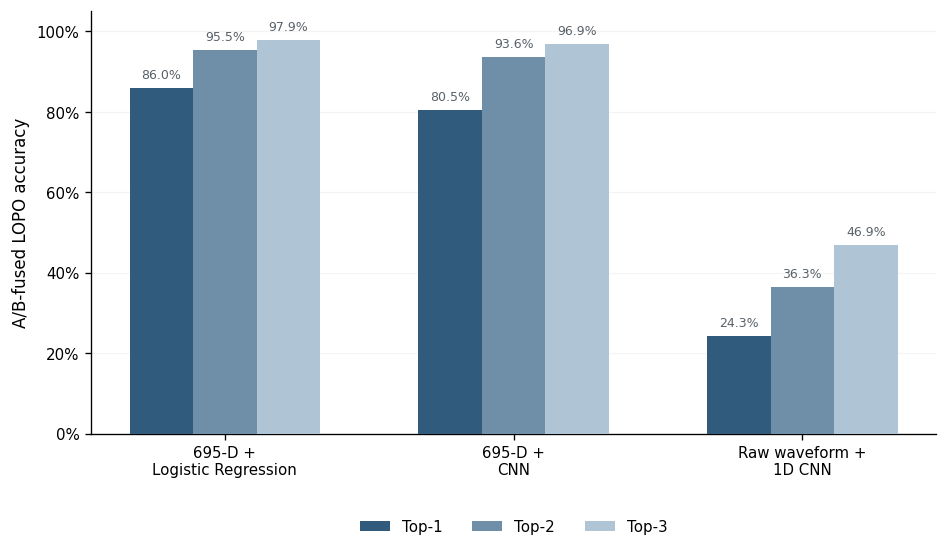

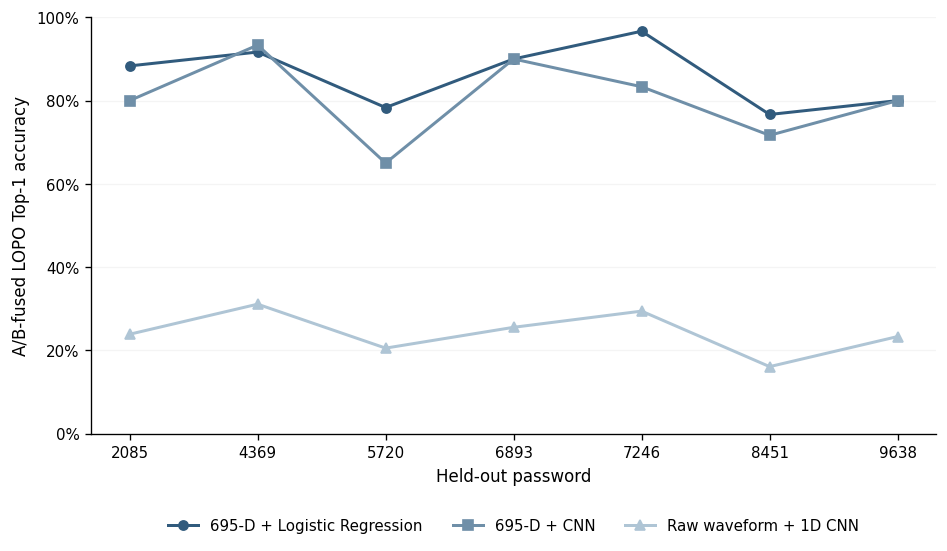

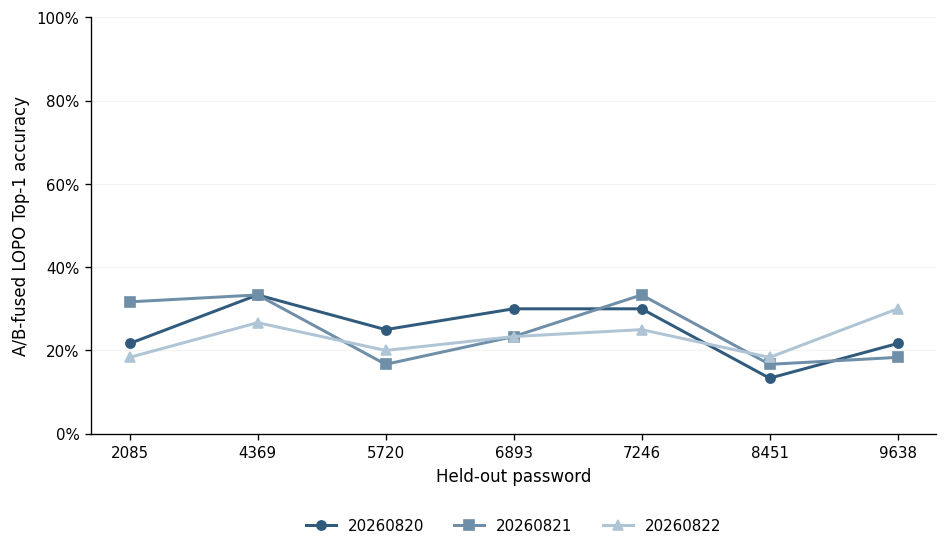

RQ18 figures redrawn.


In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "RESULT_DIR" in globals():
    RESULT_DIR = Path(RESULT_DIR)
else:
    candidates = [
        Path("/content/drive/MyDrive/Padlock_Reproduction_v1/results/18_RQ18_Engineered_vs_Raw_Waveform"),
        Path("/content/drive/MyDrive/Padlock_Reproduction_v1/Padlock_Reproduction_v1/results/18_RQ18_Engineered_vs_Raw_Waveform"),
    ]
    RESULT_DIR = next((p for p in candidates if p.exists()), None)

    if RESULT_DIR is None:
        raise FileNotFoundError("Could not locate the RQ18 result folder.")

print("Result folder:", RESULT_DIR)

representation_summary = pd.read_csv(
    RESULT_DIR / "RQ18_Representation_Summary.csv"
)

password_summary = pd.read_csv(
    RESULT_DIR / "RQ18_Password_Summary.csv"
)

raw_decisions = pd.read_csv(
    RESULT_DIR / "RQ18_RawCNN_Decisions.csv"
)

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_figure(fig, stem):
    fig.savefig(
        RESULT_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        RESULT_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )

condition_order = [
    "695-D + Logistic Regression",
    "695-D + CNN",
    "Raw waveform + 1D CNN",
]

password_order = [
    "2085",
    "4369",
    "5720",
    "6893",
    "7246",
    "8451",
    "9638",
]

# Figure 1: overall Top-k comparison

summary = (
    representation_summary
    .set_index("condition")
    .reindex(condition_order)
)

fig, ax = plt.subplots(figsize=(8.0, 4.6))

x = np.arange(len(condition_order))
width = 0.22

metric_info = [
    ("top1", "Top-1", DARK_BLUE),
    ("top2", "Top-2", MID_BLUE),
    ("top3", "Top-3", LIGHT_BLUE),
]

for i, (metric, label, color) in enumerate(metric_info):
    offset = (i - 1) * width
    values = 100 * summary[metric].to_numpy(dtype=float)

    bars = ax.bar(
        x + offset,
        values,
        width=width,
        color=color,
        edgecolor="none",
        label=label,
        zorder=3,
    )

    for bar, value in zip(bars, values):
        ax.annotate(
            f"{value:.1f}%",
            (
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color=DARK_GREY,
        )

ax.set_xticks(x)
ax.set_xticklabels([
    "695-D +\nLogistic Regression",
    "695-D +\nCNN",
    "Raw waveform +\n1D CNN",
])

ax.set_ylabel("A/B-fused LOPO accuracy")
ax.set_ylim(0, 105)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f"{y:.0f}%")
)

ax.grid(axis="y", alpha=0.13, zorder=0)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
)

fig.subplots_adjust(bottom=0.25)
fig.tight_layout()

save_figure(fig, "RQ18_Fig1_Overall_TopK")
plt.show()

# Figure 2: cross-password generalisation

password_plot = password_summary.copy()
password_plot["password"] = password_plot["password"].astype(str)

password_matrix = (
    password_plot
    .pivot(
        index="password",
        columns="condition",
        values="top1",
    )
    .reindex(
        index=password_order,
        columns=condition_order,
    )
)

fig, ax = plt.subplots(figsize=(8.0, 4.6))

style_map = {
    "695-D + Logistic Regression": {
        "color": DARK_BLUE,
        "marker": "o",
    },
    "695-D + CNN": {
        "color": MID_BLUE,
        "marker": "s",
    },
    "Raw waveform + 1D CNN": {
        "color": LIGHT_BLUE,
        "marker": "^",
    },
}

x = np.arange(len(password_order))

for condition in condition_order:
    values = 100 * password_matrix[condition].to_numpy(dtype=float)

    ax.plot(
        x,
        values,
        color=style_map[condition]["color"],
        marker=style_map[condition]["marker"],
        linewidth=1.8,
        markersize=5.5,
        label=condition,
        zorder=3,
    )

ax.set_xticks(x)
ax.set_xticklabels(password_order)

ax.set_xlabel("Held-out password")
ax.set_ylabel("A/B-fused LOPO Top-1 accuracy")
ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f"{y:.0f}%")
)

ax.grid(axis="y", alpha=0.13, zorder=0)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
)

fig.subplots_adjust(bottom=0.25)
fig.tight_layout()

save_figure(fig, "RQ18_Fig2_Password_Top1")
plt.show()

# Figure 3: raw-CNN seed stability

raw_seed_password = (
    raw_decisions
    .groupby(
        ["seed", "password"],
        as_index=False,
    )["top1"]
    .mean()
)

raw_seed_password["password"] = raw_seed_password["password"].astype(str)

seed_order = sorted(
    raw_seed_password["seed"]
    .unique()
    .tolist()
)

seed_matrix = (
    raw_seed_password
    .pivot(
        index="password",
        columns="seed",
        values="top1",
    )
    .reindex(
        index=password_order,
        columns=seed_order,
    )
)

fig, ax = plt.subplots(figsize=(8.0, 4.6))

seed_colors = [
    DARK_BLUE,
    MID_BLUE,
    LIGHT_BLUE,
]

seed_markers = [
    "o",
    "s",
    "^",
]

x = np.arange(len(password_order))

for seed, color, marker in zip(
    seed_order,
    seed_colors,
    seed_markers,
):
    values = 100 * seed_matrix[seed].to_numpy(dtype=float)

    ax.plot(
        x,
        values,
        color=color,
        marker=marker,
        linewidth=1.8,
        markersize=5.5,
        label=str(seed),
        zorder=3,
    )

ax.set_xticks(x)
ax.set_xticklabels(password_order)

ax.set_xlabel("Held-out password")
ax.set_ylabel("A/B-fused LOPO Top-1 accuracy")
ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f"{y:.0f}%")
)

ax.grid(axis="y", alpha=0.13, zorder=0)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.17),
)

fig.subplots_adjust(bottom=0.25)
fig.tight_layout()

save_figure(fig, "RQ18_Fig3_RawCNN_Seed_Stability")
plt.show()

print("RQ18 figures redrawn.")

## Interpretation boundary

This RQ answers a **representation/generalisation** question for the dissertation. It does not select a replacement operational model.

- If raw waveform + 1D CNN improves both mean LOPO Top-1 and password-level stability, this supports end-to-end learning.
- If raw CNN improves over 695-D + CNN but remains below 695-D + Logistic Regression, representation helps the CNN but the engineered pipeline remains the stronger controlled benchmark.
- If raw CNN has higher password variance or a worse worst-password result, that is evidence of greater sensitivity to password/session-specific waveform structure.
- **MAIN v8 remains the deployed True-Gate model regardless of this ablation.**